# Brain Tumor Classification with EfficientNetB0 (Fine-Tuning)

Dataset: [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

This notebook follows the same pipeline structure as the VGG16 version, but swaps in **EfficientNetB0** as the backbone and uses a proper **two-phase transfer learning + fine-tuning** strategy (feature extraction first, then fine-tuning the top layers with a low learning rate).

In [1]:
import os
import numpy as np
import random
import json
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import shuffle
import matplotlib.pyplot as plt


In [2]:
train_dir = r"Dataset/archive/Training"
test_dir  = r"Dataset/archive/Testing"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


In [3]:
# Define CLASS_LABELS ONCE using sorted() so order is always consistent
CLASS_LABELS = sorted(os.listdir(train_dir))
print("Class label order (fixed):", CLASS_LABELS)
print(f"Number of classes: {len(CLASS_LABELS)}")


Class label order (fixed): ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


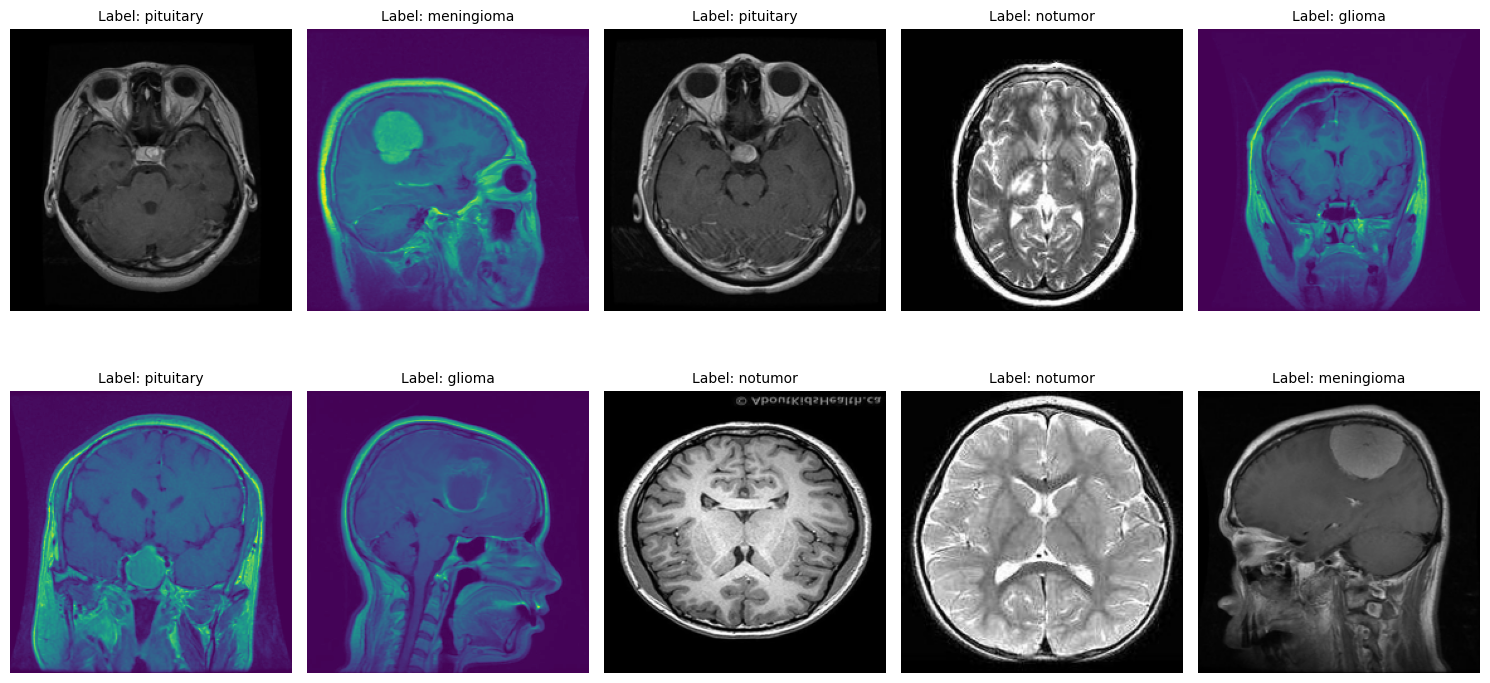

In [4]:
# Visualize some training samples
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img = Image.open(train_paths[idx]).resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


## Image loading & augmentation

EfficientNet expects images sized **224x224** and preprocessed with its own `preprocess_input` (it normalizes pixel values internally) — **do not** manually rescale to [0, 1] like with VGG16.

In [5]:
IMAGE_SIZE = 224  # EfficientNetB0 default input size

# Image Augmentation
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image)
    return image

# Load images (kept in raw 0-255 range; preprocess_input handles normalization)
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image)
        image = augment_image(image)
        images.append(image)
    images = np.array(images)
    return preprocess_input(images)


def encode_label(labels):
    return np.array([CLASS_LABELS.index(label) for label in labels])

# Data generator
def datagen(paths, labels, batch_size=20, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths  = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = encode_label(labels[i:i + batch_size])
            yield batch_images, batch_labels


## Build the model

**Phase 1 — Feature extraction:** freeze the entire EfficientNetB0 backbone and train only the new classification head.

**Phase 2 — Fine-tuning:** unfreeze the top block(s) of the backbone and continue training with a much smaller learning rate, so the pretrained ImageNet features are nudged toward MRI features instead of being destroyed.

In [6]:
# Build Model
base_model = EfficientNetB0(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Phase 1: freeze the entire backbone
base_model.trainable = False

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(CLASS_LABELS), activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,175 (16.09 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Phase 1 training — train the classification head only

In [7]:
# Train the Model (Phase 1: frozen backbone)
batch_size = 20
epochs_phase1 = 5
steps = int(len(train_paths) / batch_size)

history1 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase1),
    epochs=epochs_phase1,
    steps_per_epoch=steps
)


Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - loss: 0.8179 - sparse_categorical_accuracy: 0.7283
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 197s 703ms/step - loss: 0.3697 - sparse_categorical_accuracy: 0.8707
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 194s 691ms/step - loss: 0.2942 - sparse_categorical_accuracy: 0.8911
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 216s 771ms/step - loss: 0.2384 - sparse_categorical_accuracy: 0.9112
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 210s 751ms/step - loss: 0.2077 - sparse_categorical_accuracy: 0.9216


### Phase 2 training — unfreeze top layers and fine-tune

Unfreeze the last ~30 layers of EfficientNetB0 (the later blocks learn the most task-specific features) and continue training with a low learning rate.

In [8]:
# Phase 2: unfreeze the top layers of the backbone for fine-tuning
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30  # unfreeze last 30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNorm layers frozen even inside the unfrozen block (best practice for fine-tuning)
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,175 (16.09 MB)

 Trainable params: 1,650,404 (6.30 MB)

 Non-trainable params: 2,568,771 (9.80 MB)

In [9]:
epochs_phase2 = 10

callbacks = [
    EarlyStopping(monitor='loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, min_lr=1e-7)
]

history2 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase2),
    epochs=epochs_phase2,
    steps_per_epoch=steps,
    callbacks=callbacks
)


Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - loss: 0.1655 - sparse_categorical_accuracy: 0.9361 - learning_rate: 1.0000e-05
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - loss: 0.1356 - sparse_categorical_accuracy: 0.9467 - learning_rate: 1.0000e-05
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - loss: 0.1512 - sparse_categorical_accuracy: 0.9452 - learning_rate: 1.0000e-05
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 210s 750ms/step - loss: 0.1380 - sparse_categorical_accuracy: 0.9437 - learning_rate: 1.0000e-05
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 210s 750ms/step - loss: 0.1242 - sparse_categorical_accuracy: 0.9531 - learning_rate: 1.0000e-05
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 213s 762ms/step - loss: 0.1251 - sparse_categorical_accuracy: 0.9527 - learning_rate: 1.0000e-05
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 262s 938ms/step - loss: 0.1015 - sparse_categorical_accuracy: 0.9655 - learning_rate: 1.0000e-05
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/st

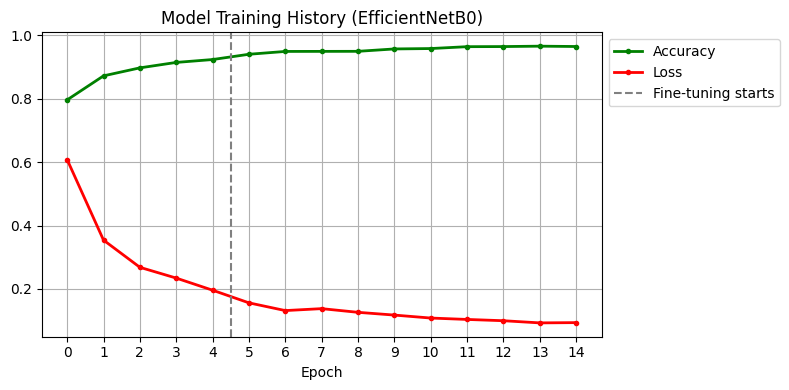

In [10]:
# Combine history from both phases for plotting
acc = history1.history['sparse_categorical_accuracy'] + history2.history['sparse_categorical_accuracy']
loss = history1.history['loss'] + history2.history['loss']
total_epochs = epochs_phase1 + len(history2.history['loss'])

plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(acc, '.g-', linewidth=2)
plt.plot(loss, '.r-', linewidth=2)
plt.axvline(x=epochs_phase1 - 0.5, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Model Training History (EfficientNetB0)')
plt.xlabel('Epoch')
plt.xticks(range(total_epochs))
plt.legend(['Accuracy', 'Loss', 'Fine-tuning starts'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [11]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate on test data
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)
predicted_classes = np.argmax(test_predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, predicted_classes, target_names=CLASS_LABELS))


50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.74      0.84       400
  meningioma       0.85      0.95      0.90       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



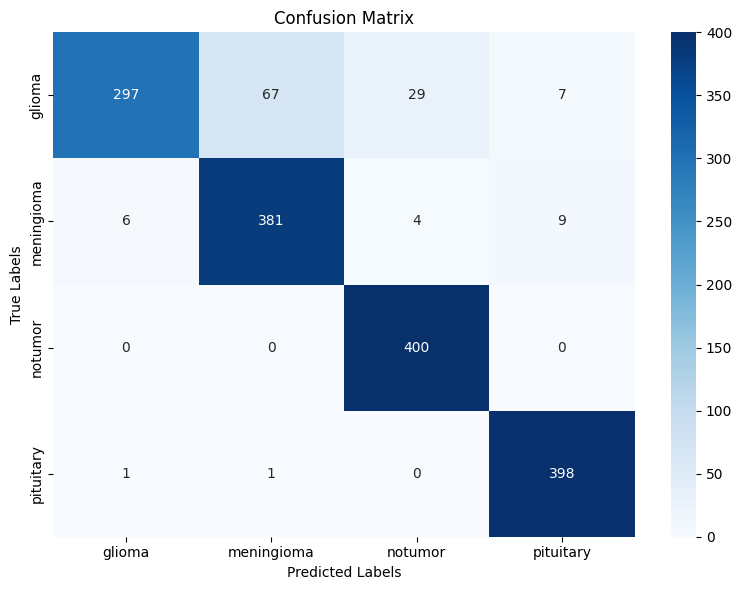

In [12]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()


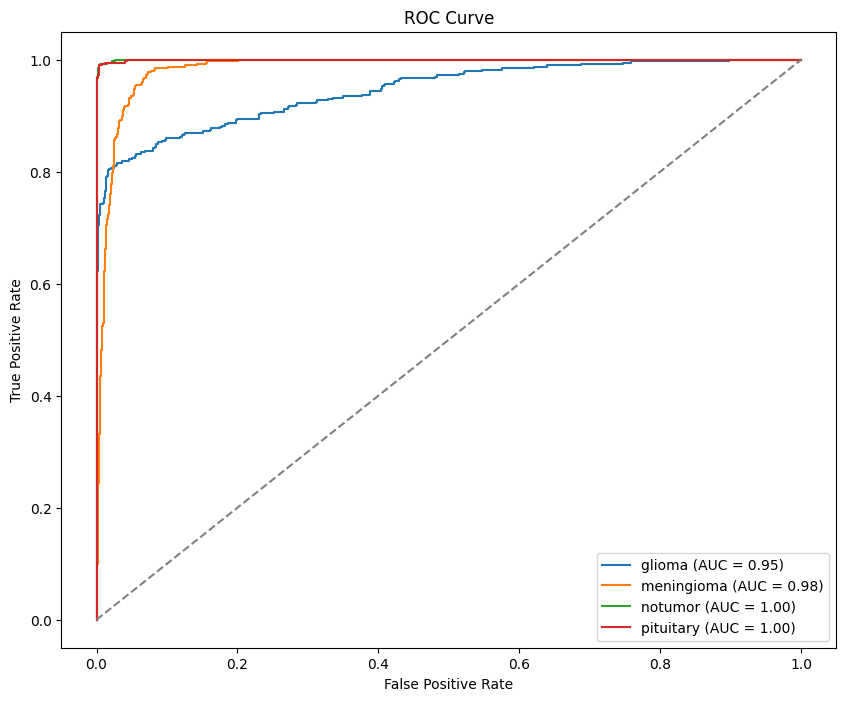

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ROC Curve
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(CLASS_LABELS)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(CLASS_LABELS)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(CLASS_LABELS)):
    plt.plot(fpr[i], tpr[i], label=f'{CLASS_LABELS[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [14]:
# Save the model
model.save('model_efficientnet.h5')
print("Model saved as model_efficientnet.h5")

# Also save CLASS_LABELS so you can load them later without retraining
with open('class_labels.json', 'w') as f:
    json.dump(CLASS_LABELS, f)
print("Class labels saved as class_labels.json:", CLASS_LABELS)


Model saved as model_efficientnet.h5
Class labels saved as class_labels.json: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:
# Load model (optional — run only if restarting kernel)
model = load_model('model_efficientnet.h5')

with open('class_labels.json') as f:
    CLASS_LABELS = json.load(f)

print("Model loaded. Class labels:", CLASS_LABELS)


Model loaded. Class labels: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [16]:
# Prediction function
def detect_and_display(img_path, model, image_size=224):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0]

        predicted_label = CLASS_LABELS[predicted_index]

        if predicted_label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_label}"

        # Show all class probabilities
        print("Probabilities:")
        for i, label in enumerate(CLASS_LABELS):
            print(f"  {label}: {predictions[0][i]*100:.2f}%")

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Probabilities:
  glioma: 0.03%
  meningioma: 0.03%
  notumor: 99.94%
  pituitary: 0.00%


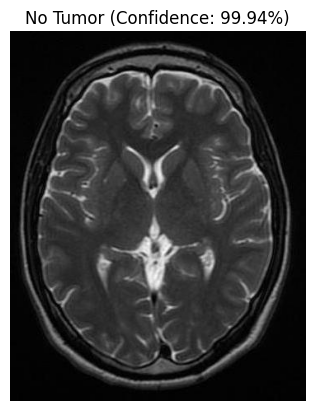

In [17]:
# Test prediction — No Tumor
image_path = r'Dataset/archive/Testing/notumor/Te-no_4.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Probabilities:
  glioma: 0.01%
  meningioma: 26.54%
  notumor: 0.08%
  pituitary: 73.38%


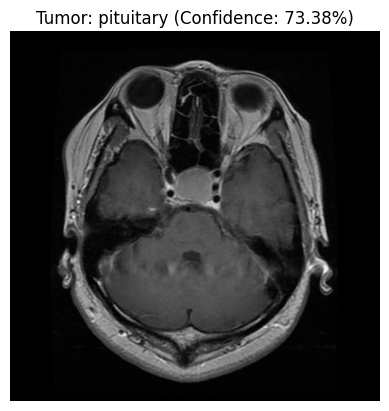

In [18]:
# Test prediction — Pituitary Tumor
image_path = r'Dataset/archive/Training/pituitary/Tr-pi_3.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 892ms/step
Probabilities:
  glioma: 0.07%
  meningioma: 99.89%
  notumor: 0.00%
  pituitary: 0.04%


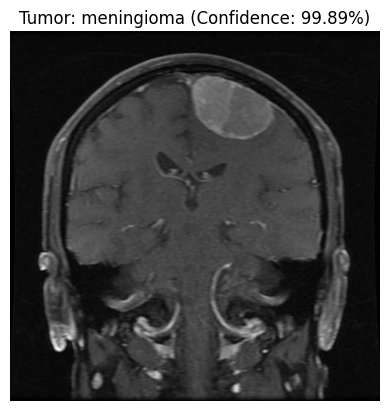

In [24]:
# Test prediction — Meningioma Tumor
image_path = r'Dataset\archive\Testing\meningioma\Te-me_1.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Probabilities:
  glioma: 99.73%
  meningioma: 0.26%
  notumor: 0.01%
  pituitary: 0.00%


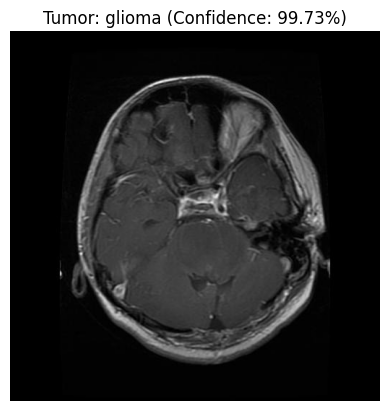

In [25]:
# Test prediction — Pituitary Tumor
image_path = r'brain_tumor_mris\Testing\glioma\Te-gl_0010.jpg'
detect_and_display(image_path, model)
